In [ ]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../shared_utils")
from experiment_utils import get_forward_model
from sc_exp_design.constants import DataFields
import torch.nn.functional as F

## Initialize recipes to predict for 

In [2]:
recipes_to_predict = np.array([[10.00, 25.00, 750, 560, 0, 10, 0, 0, 0, 0, 20, 14, 0, 0, 0],
                               [10.00, 100.00, 750, 560, 0, 10,	0, 0, 0, 0,	20, 14, 0, 0, 0]])
recipes_to_predict = np.log1p(recipes_to_predict)

recipes_to_predict_t = torch.from_numpy(recipes_to_predict).unsqueeze(0).repeat(5000, 1, 1)

In [3]:
recipes_to_predict

array([[2.39789527, 3.25809654, 6.62140565, 6.32972091, 0.        ,
        2.39789527, 0.        , 0.        , 0.        , 0.        ,
        3.04452244, 2.7080502 , 0.        , 0.        , 0.        ],
       [2.39789527, 4.61512052, 6.62140565, 6.32972091, 0.        ,
        2.39789527, 0.        , 0.        , 0.        , 0.        ,
        3.04452244, 2.7080502 , 0.        , 0.        , 0.        ]])

# Collect ground truths 

In [4]:
adata_l4 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop4/replicate/processed/adata_loop4_500k_residual_processed.h5ad")
adata_l4p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop4/replicate/processed/adata_loop4p5_500k_residual_processed.h5ad")

In [5]:
gt_l4 = adata_l4.obs.cell_type.value_counts() / adata_l4.shape[0]
gt_l4p5 = adata_l4p5.obs.cell_type.value_counts() / adata_l4p5.shape[0]

# Load loop3 fwd model 

In [6]:
with initialize(config_path="../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                     overrides=[
                        "paths=loop3_replicate",
                        "annotation=bloodplus_loop3"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [7]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [8]:
train_adata_g = target_prediction_model.train_data.adata

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [9]:
condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
recipes_to_predict_t = recipes_to_predict_t.to(forward_model.device).float()

batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: recipes_to_predict_t}}
forward_out = forward_model.predict(
    batch_dict,
    no_grad=True,
    fix_noise=False,
    num_time_steps=100
)
# Collect predictions 
y_pred = forward_out["target_prediction_data"]["cell_type"].view(recipes_to_predict_t.shape[0], 
                                                                 recipes_to_predict_t.shape[1], 
                                                                 len(classes))  
y_pred_softmax = F.softmax(y_pred, dim=-1)

In [10]:
y_pred_pred = y_pred_softmax.argmax(-1).cpu().numpy()
pred_classes_loop3 = classes[y_pred_pred]

In [11]:
pred_l3_tpo25 = pd.DataFrame(pred_classes_loop3[:,0])
pred_l3_tpo100 = pd.DataFrame(pred_classes_loop3[:,1])

pred_l3_tpo25 = pred_l3_tpo25.value_counts() / pred_l3_tpo25.shape[0]
pred_l3_tpo100 = pred_l3_tpo100.value_counts() / pred_l3_tpo100.shape[0]

In [12]:
l3_model_l4_res = {"data_type": [], 
                  "cell_type": [], 
                  "prop": []}

l3_model_l4p5_res = {"data_type": [], 
                     "cell_type": [], 
                     "prop": []}

In [13]:
for cl in classes:
    l3_model_l4_res["data_type"].append("Predicted")
    l3_model_l4_res["cell_type"].append(cl)
    try:
        l3_model_l4_res["prop"].append(pred_l3_tpo25[cl])
    except:
        l3_model_l4_res["prop"].append(0)

    l3_model_l4_res["data_type"].append("Ground truth")
    l3_model_l4_res["cell_type"].append(cl)
    try:
        l3_model_l4_res["prop"].append(gt_l4[cl])
    except:
        l3_model_l4_res["prop"].append(0)

    l3_model_l4p5_res["data_type"].append("Predicted")
    l3_model_l4p5_res["cell_type"].append(cl)
    try:
        l3_model_l4p5_res["prop"].append(pred_l3_tpo100[cl])
    except:
        l3_model_l4p5_res["prop"].append(0)

    l3_model_l4p5_res["data_type"].append("Ground truth")
    l3_model_l4p5_res["cell_type"].append(cl)
    try:
        l3_model_l4p5_res["prop"].append(gt_l4p5[cl])
    except:
        l3_model_l4p5_res["prop"].append(0)

In [14]:
l3_model_l4_res_df = pd.DataFrame(l3_model_l4_res)
l3_model_l4p5_res_df = pd.DataFrame(l3_model_l4p5_res)

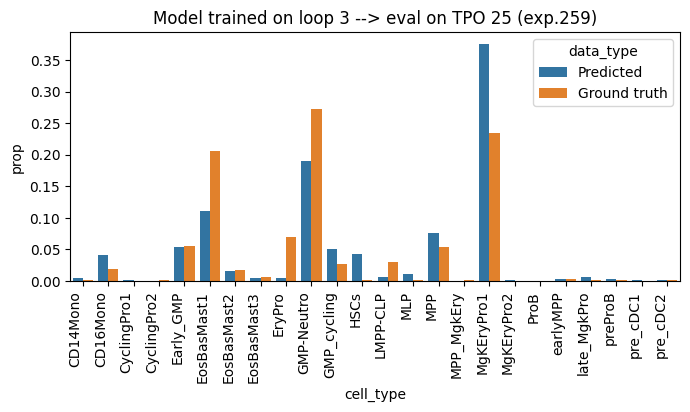

In [15]:
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l3_model_l4_res_df,
    x="cell_type",
    y="prop",
    hue="data_type"
)

plt.xticks(rotation=90, ha="right")  # or rotation=90
plt.tight_layout()                   # prevents labels from being cut off
plt.title("Model trained on loop 3 --> eval on TPO 25 (exp.259)")
plt.show()

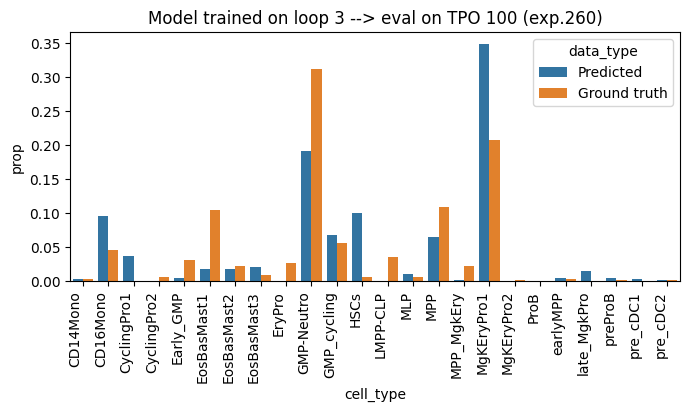

In [16]:
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l3_model_l4p5_res_df,
    x="cell_type",
    y="prop",
    hue="data_type"
)

plt.xticks(rotation=90, ha="right")  # or rotation=90
plt.tight_layout()                   # prevents labels from being cut off
plt.title("Model trained on loop 3 --> eval on TPO 100 (exp.260)")
plt.show()

In [17]:
pred_l3_tpo25

0          
MgKEryPro1     0.3758
GMP-Neutro     0.1892
EosBasMast1    0.1108
MPP            0.0756
Early_GMP      0.0540
GMP_cycling    0.0510
HSCs           0.0416
CD16Mono       0.0402
EosBasMast2    0.0148
MLP            0.0112
late_MgkPro    0.0064
LMPP-CLP       0.0054
CD14Mono       0.0050
EosBasMast3    0.0048
EryPro         0.0044
earlyMPP       0.0034
preProB        0.0026
pre_cDC1       0.0018
CyclingPro1    0.0006
MgKEryPro2     0.0006
pre_cDC2       0.0006
MPP_MgkEry     0.0002
Name: count, dtype: float64

In [18]:
pred_l3_tpo100

0          
MgKEryPro1     0.3494
GMP-Neutro     0.1906
HSCs           0.0996
CD16Mono       0.0956
GMP_cycling    0.0672
MPP            0.0648
CyclingPro1    0.0362
EosBasMast3    0.0208
EosBasMast1    0.0168
EosBasMast2    0.0166
late_MgkPro    0.0150
MLP            0.0098
earlyMPP       0.0038
Early_GMP      0.0036
preProB        0.0034
CD14Mono       0.0026
pre_cDC1       0.0026
pre_cDC2       0.0012
MPP_MgkEry     0.0004
Name: count, dtype: float64

# Load loop4 fwd model 

In [19]:
with initialize(config_path="../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                     overrides=[
                        "paths=loop4_replicate",
                        "annotation=bloodplus_loop3"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [ ]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [ ]:
train_adata_g = target_prediction_model.train_data.adata

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [ ]:
condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
recipes_to_predict_t = recipes_to_predict_t.to(forward_model.device).float()

batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: recipes_to_predict_t}}
forward_out = forward_model.predict(
    batch_dict,
    no_grad=True,
    fix_noise=False,
    num_time_steps=100
)
# Collect predictions 
y_pred = forward_out["target_prediction_data"]["cell_type"].view(recipes_to_predict_t.shape[0], 
                                                                 recipes_to_predict_t.shape[1], 
                                                                 len(classes))  
y_pred_softmax = F.softmax(y_pred, dim=-1)

In [ ]:
y_pred_pred = y_pred_softmax.argmax(-1).cpu().numpy()
pred_classes_loop4 = classes[y_pred_pred]

In [ ]:
pred_l4_tpo25 = pd.DataFrame(pred_classes_loop4[:,0])
pred_l4_tpo100 = pd.DataFrame(pred_classes_loop4[:,1])

pred_l4_tpo25 = pred_l4_tpo25.value_counts() / pred_l4_tpo25.shape[0]
pred_l4_tpo100 = pred_l4_tpo100.value_counts() / pred_l4_tpo100.shape[0]

In [ ]:
l4_model_l4_res = {"data_type": [], 
                  "cell_type": [], 
                  "prop": []}

l4_model_l4p5_res = {"data_type": [], 
                     "cell_type": [], 
                     "prop": []}

In [ ]:
for cl in classes:
    l4_model_l4_res["data_type"].append("Predicted")
    l4_model_l4_res["cell_type"].append(cl)
    try:
        l4_model_l4_res["prop"].append(pred_l4_tpo25[cl])
    except:
        l4_model_l4_res["prop"].append(0)

    l4_model_l4_res["data_type"].append("Ground truth")
    l4_model_l4_res["cell_type"].append(cl)
    try:
        l4_model_l4_res["prop"].append(gt_l4[cl])
    except:
        l4_model_l4_res["prop"].append(0)

    l4_model_l4p5_res["data_type"].append("Predicted")
    l4_model_l4p5_res["cell_type"].append(cl)
    try:
        l4_model_l4p5_res["prop"].append(pred_l4_tpo100[cl])
    except:
        l4_model_l4p5_res["prop"].append(0)

    l4_model_l4p5_res["data_type"].append("Ground truth")
    l4_model_l4p5_res["cell_type"].append(cl)
    try:
        l4_model_l4p5_res["prop"].append(gt_l4p5[cl])
    except:
        l4_model_l4p5_res["prop"].append(0)

In [ ]:
l4_model_l4_res_df = pd.DataFrame(l4_model_l4_res)
l4_model_l4p5_res_df = pd.DataFrame(l4_model_l4p5_res)

In [ ]:
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l4_model_l4_res_df,
    x="cell_type",
    y="prop",
    hue="data_type"
)

plt.xticks(rotation=90, ha="right")  # or rotation=90
plt.tight_layout()                   # prevents labels from being cut off
plt.title("Model trained on loop 4 (after seeing TPO 25, TPO 100 remains unseen) --> eval on TPO 25 (exp.259)")
plt.show()

In [ ]:
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l4_model_l4p5_res_df,
    x="cell_type",
    y="prop",
    hue="data_type"
)

plt.xticks(rotation=90, ha="right")  # or rotation=90
plt.tight_layout()                   # prevents labels from being cut off
plt.title("Model trained on loop 4 (after seeing TPO 25, TPO 100 remains unseen) --> eval on TPO 100 (exp.260)")
plt.show()